# Phase 1 — ML results on the official test set

Issue #6. This is the final Phase 1 comparison: Random Forest, XGBoost and Elastic Net on the **official FD001 test engines**, each scored once at its **last recorded cycle** against `RUL_FD001.txt`.

**Protocol.** The target is uncapped RUL. Hyperparameters are chosen by cross-validation on the 100 training engines only, using three engine-grouped folds (seed 42). The pipelines and grids are the ones from #18 (`rul.models.experiment`), so sensor selection and regime normalization are refitted inside every fold. The best setting is then refitted on all 100 training engines and predicts each test engine from its full recorded history. The test engines are never used to choose anything.

Both feature sets from #18 are reported. **Engineered** features (selected sensors, regime z-scores and causal rolling mean, slope and health change over 5, 10 and 20 cycles) are the Phase 1 method, so they fill the README. **Raw** inputs (cycle, settings, all 21 sensors) are the reference.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.model_selection import GridSearchCV

from rul.data.labels import add_train_rul
from rul.data.load import load_subset
from rul.data.split import group_kfold_splits
from rul.evaluation.official import predict_test_cycles, save_results, score_last_cycle
from rul.models.experiment import COMPARISON_GRIDS, make_comparison_models

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
SUBSET, SEED, N_SPLITS = "FD001", 42, 3
MODELS = {"random_forest": "Random Forest", "xgboost": "XGBoost", "elastic_net": "Elastic Net"}
VARIANTS = ("engineered", "raw")

train, test, rul_test = load_subset(SUBSET, data_dir=ROOT / "data/raw/CMAPSSData")
train = add_train_rul(train)  # uncapped RUL, the primary target
folds = list(group_kfold_splits(train, n_splits=N_SPLITS, seed=SEED))
for fit_rows, check_rows in folds:
    assert set(train["unit"].iloc[fit_rows]).isdisjoint(train["unit"].iloc[check_rows])
print(f"{SUBSET}: {train['unit'].nunique()} training engines ({len(train):,} cycles), "
      f"{test['unit'].nunique()} test engines ({len(test):,} cycles)")

FD001: 100 training engines (20,631 cycles), 100 test engines (13,096 cycles)


## 1. Tune on the training engines, then refit

Each model searches the same four candidates as in #18 over the same three folds, for both feature sets. `GridSearchCV` then refits the best candidate on all 100 training engines. Parallel search changes run time only: every model has a fixed seed.

In [2]:
X_train = train.drop(columns="rul")
searches = {}
for variant in VARIANTS:
    for name, pipeline in make_comparison_models(engineered=variant == "engineered", seed=SEED).items():
        search = GridSearchCV(pipeline, COMPARISON_GRIDS[name], cv=folds,
                              scoring="neg_root_mean_squared_error", n_jobs=-1, error_score="raise")
        searches[variant, name] = search.fit(X_train, train["rul"])

tuning = pd.DataFrame([
    {"features": variant, "model": MODELS[name], "cv_rmse": -search.best_score_,
     "cv_rmse_std": search.cv_results_["std_test_score"][search.best_index_],
     "best_params": search.best_params_}
    for (variant, name), search in searches.items()
])
display(tuning.round(2))

,features,model,cv_rmse,cv_rmse_std,best_params
0,engineered,Random Forest,36.39,4.97,"{'model__min_samples_leaf': 1, 'model__n_estim..."
1,engineered,XGBoost,37.98,5.12,"{'model__max_depth': 5, 'model__n_estimators':..."
2,engineered,Elastic Net,41.83,3.79,"{'model__model__alpha': 1.0, 'model__model__l1..."
3,raw,Random Forest,37.59,3.77,"{'model__min_samples_leaf': 3, 'model__n_estim..."
4,raw,XGBoost,38.06,3.72,"{'model__max_depth': 3, 'model__n_estimators':..."
5,raw,Elastic Net,40.68,4.84,"{'model__model__alpha': 0.1, 'model__model__l1..."


## 2. Score each test engine at its last cycle

`predict_test_cycles` gives the model every recorded cycle of each test engine (rolling features need the history) and never shows it the true RUL. `score_last_cycle` keeps one row per engine, the last cycle, where the true RUL is the value in `RUL_FD001.txt`. Lower is better for all three metrics. Stages follow the true RUL: late ≤ 50 < mid ≤ 100 < early.

In [3]:
scores, last_rows, cycle_predictions = {}, {}, {}
for (variant, name), search in searches.items():
    cycle_predictions[variant, name] = predict_test_cycles(search, test, rul_test)
    last_rows[variant, name], scores[variant, name] = score_last_cycle(cycle_predictions[variant, name])

overall = pd.DataFrame([
    {"features": variant, "model": MODELS[name], "engines": m["n"],
     "RMSE": m["rmse"], "MAE": m["mae"], "NASA score": m["nasa_score"]}
    for (variant, name), m in scores.items()
])
display(overall.round(2))

by_stage = pd.DataFrame([
    {"features": variant, "model": MODELS[name], "stage": stage, "engines": s["n"],
     "RMSE": s["rmse"], "MAE": s["mae"], "NASA score": s["nasa_score"]}
    for (variant, name), m in scores.items() for stage, s in m["by_stage"].items()
])
display(by_stage.round(2))

,features,model,engines,RMSE,MAE,NASA score
0,engineered,Random Forest,100,27.55,17.67,145409.77
1,engineered,XGBoost,100,30.50,19.82,61201.74
2,engineered,Elastic Net,100,28.39,23.57,7776.72
3,raw,Random Forest,100,26.15,19.22,8414.50
4,raw,XGBoost,100,26.84,19.19,7001.52
5,raw,Elastic Net,100,31.08,25.80,6903.01


,features,model,stage,engines,RMSE,MAE,NASA score
0,engineered,Random Forest,early,33,39.49,28.82,141388.34
1,engineered,Random Forest,mid,34,25.76,19.16,3983.27
2,engineered,Random Forest,late,33,7.52,4.97,38.16
3,engineered,XGBoost,early,33,43.39,31.44,59140.03
4,engineered,XGBoost,mid,34,29.62,23.60,2042.46
5,engineered,XGBoost,late,33,5.62,4.30,19.25
6,engineered,Elastic Net,early,33,27.09,21.54,5133.60
7,engineered,Elastic Net,mid,34,32.60,28.16,2178.13
8,engineered,Elastic Net,late,33,24.78,20.89,464.99
9,raw,Random Forest,early,33,32.95,28.65,2160.27


## 3. Save metrics and per-engine predictions

`results/metrics/fd001_test.json` holds the protocol, the chosen parameters, the CV RMSE and every test metric (overall and by stage). `fd001_test_predictions.csv` keeps each engine's last-cycle prediction for all six models. Phase 2 can then compare models engine by engine, for example with a paired test, instead of only by averages.

In [4]:
metrics = {
    "subset": SUBSET,
    "protocol": {
        "target": "uncapped RUL",
        "train_engines": int(train["unit"].nunique()),
        "test_engines": int(test["unit"].nunique()),
        "scored_at": f"last recorded cycle of each test engine, against RUL_{SUBSET}.txt",
        "tuning": (f"{N_SPLITS} engine-grouped CV folds over all training engines (seed {SEED}); "
                   "preprocessing refitted inside each fold; best candidate refitted on all training engines"),
        "seed": SEED,
    },
    "models": {
        variant: {
            name: {
                "best_params": searches[variant, name].best_params_,
                "cv_rmse": float(-searches[variant, name].best_score_),
                "test": scores[variant, name],
            }
            for name in MODELS
        }
        for variant in VARIANTS
    },
}

predictions = last_rows["engineered", "random_forest"][["unit", "cycle", "rul"]].reset_index(drop=True)
for (variant, name), last in last_rows.items():
    assert last["unit"].tolist() == predictions["unit"].tolist()
    predictions[f"{variant}_{name}"] = last["prediction"].to_numpy()

paths = save_results("fd001_test", metrics, predictions)
print({kind: str(path.relative_to(ROOT)) for kind, path in paths.items()})

{'metrics': 'results/metrics/fd001_test.json', 'predictions': 'results/metrics/fd001_test_predictions.csv'}


## 4. Where the largest errors come from

The NASA score adds up one exponential penalty per engine, so a single badly late prediction can dominate it. The table finds each model's worst engine by that penalty, its share of the total, and the score without it. It also counts large overestimates (more than 50 cycles too late) and impossible negative predictions.

In [5]:
from rul.evaluation.metrics import nasa_score

rows = []
for variant, name in last_rows:
    predicted = predictions[f"{variant}_{name}"]
    per_engine = pd.Series([nasa_score([t], [p]) for t, p in zip(predictions["rul"], predicted)])
    worst = per_engine.idxmax()
    rows.append({
        "features": variant, "model": MODELS[name],
        "engines over by > 50": int((predicted - predictions["rul"] > 50).sum()),
        "worst engine": int(predictions.loc[worst, "unit"]),
        "its cycles seen": int(predictions.loc[worst, "cycle"]),
        "its true / predicted RUL": f"{predictions.loc[worst, 'rul']} / {predicted[worst]:.0f}",
        "its share of NASA score": per_engine[worst] / per_engine.sum(),
        "NASA score without it": per_engine.drop(worst).sum(),
        "negative predictions": int((predicted < 0).sum()),
    })
display(pd.DataFrame(rows).round(2))

lifetimes = train.groupby("unit")["cycle"].max()
print(f"Training engines lived {lifetimes.min()}–{lifetimes.max()} cycles (median {lifetimes.median():.0f}); "
      f"true test RUL at the last cycle is {rul_test.min()}–{rul_test.max()} cycles.")

,features,model,engines over by > 50,worst engine,its cycles seen,its true / predicted RUL,its share of NASA score,NASA score without it,negative predictions
0,engineered,Random Forest,9,1,31,112 / 230,0.92,11758.06,0
1,engineered,XGBoost,11,78,72,107 / 213,0.68,19448.35,0
2,engineered,Elastic Net,8,78,72,107 / 191,0.57,3318.98,7
3,raw,Random Forest,7,15,76,83 / 167,0.52,4007.85,0
4,raw,XGBoost,10,67,71,77 / 155,0.35,4518.59,0
5,raw,Elastic Net,9,41,123,18 / 89,0.17,5725.81,2


Training engines lived 128–362 cycles (median 199); true test RUL at the last cycle is 7–145 cycles.


## 5. Figures for the report

All figures use the engineered models, the Phase 1 method, and keep each model's colour from `rul.evaluation.plots`. They are saved to `results/figures/`. The three prediction panels share one scale, and points above the diagonal are predictions of more life than the engine had.

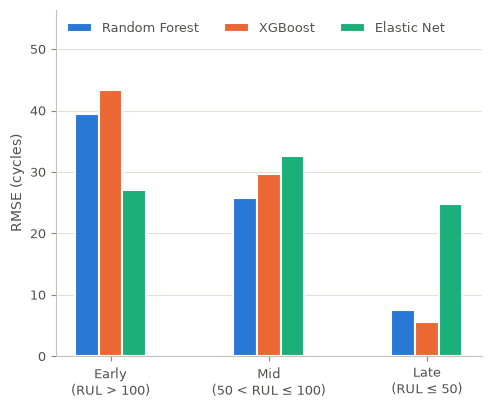

In [6]:
from rul.evaluation.plots import (
    SERIES, plot_pred_vs_true, plot_stage_errors, plot_trajectory, pred_vs_true_limits, save_figure,
)

COLOURS = dict(zip(MODELS, SERIES))

ax = plot_stage_errors({MODELS[name]: scores["engineered", name] for name in MODELS}, metric="rmse")
save_figure(ax.figure, "fd001_test_stage_rmse")
plt.show()

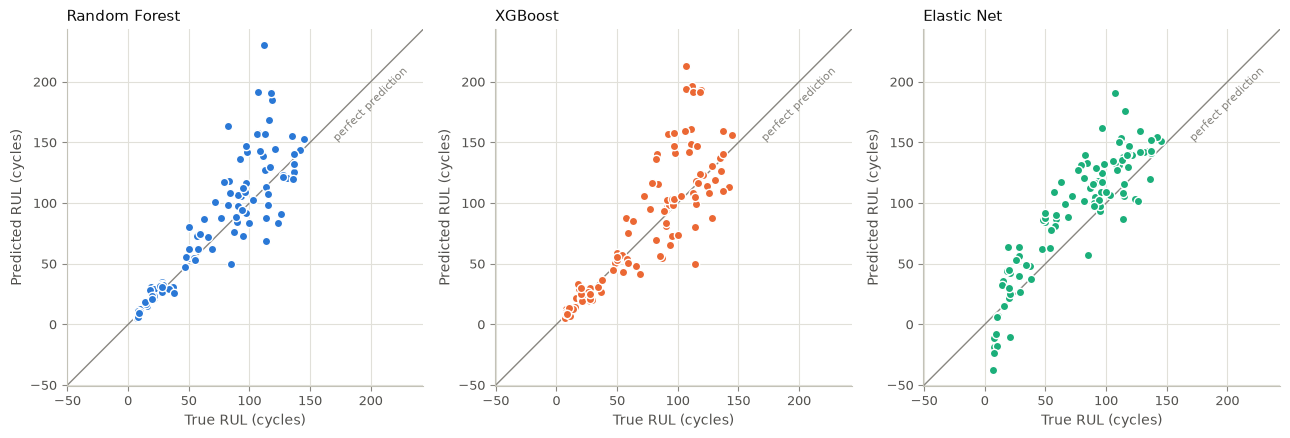

In [7]:
engineered_last = {name: last_rows["engineered", name] for name in MODELS}
limits = pred_vs_true_limits(*(values for last in engineered_last.values()
                               for values in (last["rul"], last["prediction"])))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), facecolor="#ffffff")
for ax, (name, last) in zip(axes, engineered_last.items()):
    plot_pred_vs_true(last["rul"], last["prediction"], ax=ax, title=MODELS[name],
                      color=COLOURS[name], limits=limits)
fig.tight_layout()
save_figure(fig, "fd001_test_pred_vs_true")
plt.show()

Trajectories show how the prediction evolves over a test engine's recorded life. The four engines with the **longest recorded histories** are shown, a rule that does not depend on any model's errors. The model drawn is the engineered model with the lowest test RMSE.

Model: Random Forest; engines: [49, 62, 91, 93]


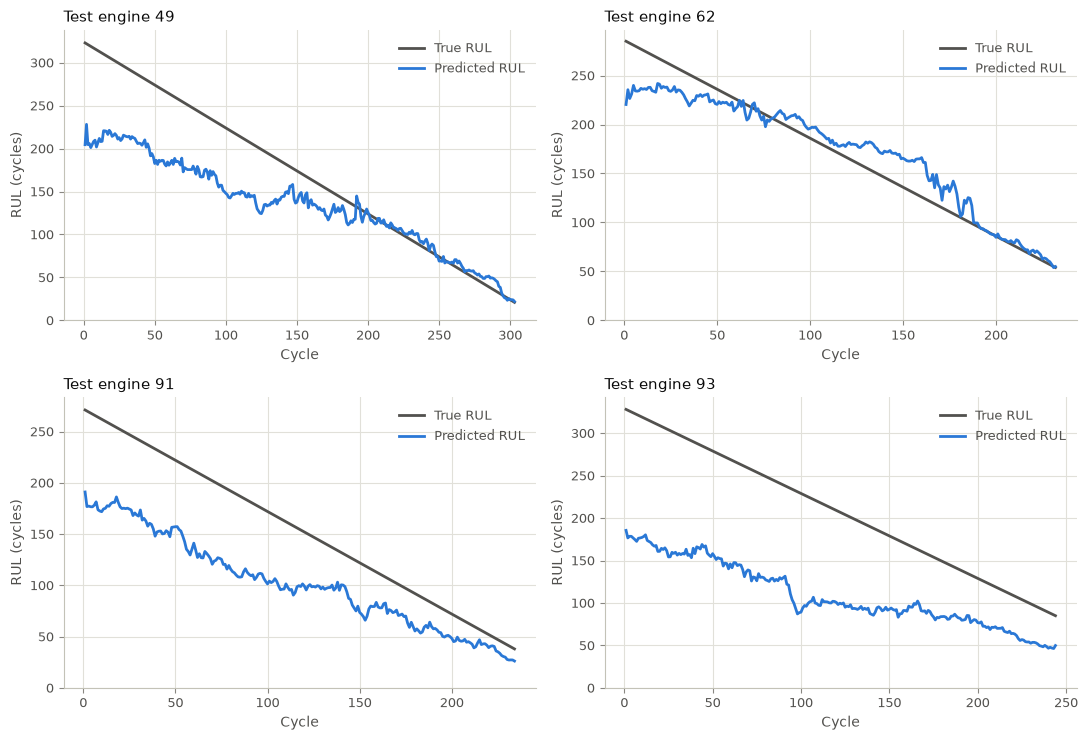

In [8]:
best = min(MODELS, key=lambda name: scores["engineered", name]["rmse"])
history = cycle_predictions["engineered", best]
longest = sorted(test.groupby("unit")["cycle"].max().nlargest(4).index)
print(f"Model: {MODELS[best]}; engines: {longest}")

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), facecolor="#ffffff")
for ax, unit in zip(axes.flat, longest):
    engine = history[history["unit"] == unit]
    plot_trajectory(engine["cycle"], engine["rul"], engine["prediction"], ax=ax,
                    title=f"Test engine {unit}", color=COLOURS[best])
fig.tight_layout()
save_figure(fig, "fd001_test_trajectories")
plt.show()

## 6. Findings

FD001 official test set, 100 engines, each scored at its last cycle, uncapped RUL.

| Model | Engineered RMSE | Engineered MAE | Engineered NASA | Raw RMSE | Raw MAE | Raw NASA |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 27.55 | **17.67** | 145,410 | **26.15** | 19.22 | 8,414 |
| XGBoost | 30.50 | 19.82 | 61,202 | 26.84 | 19.19 | 7,002 |
| Elastic Net | 28.39 | 23.57 | 7,777 | 31.08 | 25.80 | **6,903** |

1. **No single winner.** Raw-input Random Forest has the lowest RMSE (26.15), engineered Random Forest the lowest MAE (17.67), and raw Elastic Net the lowest NASA score. Engineered features lower RMSE only for Elastic Net (31.08 → 28.39); for both tree models they raise it.
2. **Engineered features win near failure.** On the 33 engines with RUL ≤ 50, RMSE falls from 13.50 to 7.52 for Random Forest and from 14.32 to 5.62 for XGBoost. This is the stage where maintenance is actually scheduled. Elastic Net stays poor there (24.78), since a linear model cannot follow the sharp fall in RUL near the end of life.
3. **They lose on young engines.** On the 33 engines with RUL > 100, the engineered trees are worse (Random Forest 39.49 vs 32.95, XGBoost 43.39 vs 33.77), and engineered Random Forest overestimates 9 engines by more than 50 cycles. With an uncapped target, an engine that still looks healthy gets the long remaining life typical of training engines, which lived 128–362 cycles. But no test engine had more than 145 cycles left at its last cycle.
4. **The NASA score is driven by single engines.** Test engine 1, seen for only 31 cycles with 112 left, is predicted at 230 by engineered Random Forest. That one engine is 92% of its 145,410; the other 99 engines add up to about 11,760. XGBoost's 61,202 has the same pattern. NASA rankings here therefore mostly reflect one or two engines, so read them together with RMSE, MAE and the stage table.
5. **Elastic Net predicts negative RUL** for 7 test engines with engineered features (2 with raw inputs). Predictions are reported as made, without clipping at zero.
6. **CV RMSE (36–42) is higher than test RMSE (26–31)** because cross-validation scores every cycle of the training engines, including very early cycles with up to 361 cycles left, while the test set scores only the last cycle, where RUL is at most 145.

**For Phase 2.** Findings 3 and 4 are what the capped-target ablation (RUL capped at 125, planned in the Phase 2 ablations) addresses. A sequence model has to beat 26.15 RMSE overall and roughly 6–8 RMSE in the late stage to improve on Phase 1.

In [9]:
from importlib.metadata import version

print({package: version(package) for package in ("numpy", "pandas", "scikit-learn", "xgboost")})

{'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'xgboost': '3.4.1'}
